# FCPS — Predictive Edge vs Baselines + Multimodal Thesis Test
**Author: Romin Patel**  ·  Kaggle: **GPU T4 x2 + Internet ON**.

This notebook answers the project's two open questions, honestly:

**Q1 — Can ANY model beat a VIX threshold out-of-sample?**  We add genuinely
VIX-orthogonal signal (full-history credit spreads, yield curve, funding,
cross-asset correlation, TDA) and sweep the target over horizons × thresholds
to find where signal exists. A config WINS only if it clears all three:
`OOS PR-AUC > VIX`  **and**  `PBO < 0.5`  **and**  `Deflated Sharpe > 0.95`.

**Q2 — Does REAL news sentiment (FinBERT) add value over price+macro?**
Decisive test: `+REAL_sentiment` must beat the same model without it under
CPCV, AND sentiment must Granger-cause forward stress.

> ⚠️ **Attach two things for the full test:** (1) a **FRED_API_KEY** secret,
> (2) a **financial-news dataset** (date + headline columns) as input. The
> notebook degrades gracefully if either is missing, but Q1/Q2 need them.

> **Honesty rule:** this notebook is built to FIND edge if it exists and to
> report a clean NULL if it doesn't. It will not manufacture a win.

## 1. Install

In [14]:
import subprocess, sys
def _pip(*pkgs):
    for p in pkgs:
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p],
                                  stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        except Exception as e:
            print(f"  (optional) {p}: {e}")
_pip("yfinance>=0.2.40", "fredapi>=0.5.2", "hmmlearn>=0.3.3", "scikit-learn>=1.3", "statsmodels>=0.14")
_pip("ripser")  # TDA (optional)
print("[OK] install done")

[OK] install done


## 2. Imports / config

In [15]:
import os, json, math, glob, warnings
from itertools import combinations
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from scipy.stats import norm, skew, kurtosis, rankdata, multivariate_normal
from scipy.special import logsumexp
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss
from hmmlearn.hmm import GaussianHMM
from statsmodels.tsa.stattools import grangercausalitytests
import matplotlib.pyplot as plt

SEED = 42; np.random.seed(SEED)
try:
    import torch; DEVICE = "cuda" if torch.cuda.is_available() else "cpu"; torch.manual_seed(SEED)
except Exception:
    DEVICE = "cpu"
START, END = "1990-01-01", "2024-12-31"
OUT = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
# Target sweep (where might signal live?)
HORIZONS = [10, 21, 63]
THRESHOLDS = [0.07, 0.10]
print("Device:", DEVICE)

Device: cuda


## 3. Data — market + FRED (credit/curve = the VIX-orthogonal signal)

In [16]:
import yfinance as yf
def dl(t):
    d = yf.download(t, start=START, end=END, auto_adjust=True, progress=False)
    if isinstance(d.columns, pd.MultiIndex): d.columns = d.columns.get_level_values(0)
    return d
market = {"sp500": dl("^GSPC"), "vix": dl("^VIX")}
for s in ["AAPL", "JPM", "XOM", "GS"]:
    try: market[s.lower()] = dl(s)
    except Exception: pass
print("S&P500", market["sp500"].shape)

fred_daily = pd.DataFrame()
try:
    from kaggle_secrets import UserSecretsClient
    key = UserSecretsClient().get_secret("FRED_API_KEY")
    from fredapi import Fred
    fred = Fred(api_key=key)
    raw = {}
    for col, sid in {"credit_spread": "BAMLH0A0HYM2", "yield_spread": "T10Y2Y",
                     "fed_funds": "FEDFUNDS", "oil_price": "DCOILWTICO",
                     "ted": "TEDRATE", "t3m": "DGS3MO"}.items():
        try: raw[col] = fred.get_series(sid, observation_start=START, observation_end=END)
        except Exception: pass
    fred_daily = pd.DataFrame(raw); fred_daily.index = pd.to_datetime(fred_daily.index)
    print("FRED OK:", list(fred_daily.columns),
          "| credit_spread non-null:", int(fred_daily.get('credit_spread', pd.Series()).notna().sum()))
except Exception as e:
    print("!!! NO FRED KEY — Q1 is severely weakened (credit spread is the key VIX-orthogonal signal).")
    print("    Add-ons -> Secrets -> FRED_API_KEY. Detail:", str(e)[:80])

S&P500 (8816, 5)
!!! NO FRED KEY — Q1 is severely weakened (credit spread is the key VIX-orthogonal signal).
    Add-ons -> Secrets -> FRED_API_KEY. Detail: Unexpected response from the service. Response: {'errors': ['No user secrets exi


## 4. Features + FSI (train-head scaler) + causal regime

In [17]:
def engineer(sp, vix):
    df = pd.DataFrame(index=sp.index)
    df["close"], df["volume"] = sp["Close"], sp["Volume"]
    df["vix"] = vix["Close"].reindex(df.index).ffill()
    df["log_ret"] = np.log(df["close"]/df["close"].shift(1))
    for w in [5,21,63,126]: df[f"vol_{w}d"] = df["log_ret"].rolling(w).std()*np.sqrt(252)
    df["drawdown_63"] = df["close"].rolling(63).apply(lambda x:(x[-1]-x.max())/x.max() if x.max() else 0.0, raw=True)
    df["vix_spike"] = (df["vix"] > df["vix"].rolling(63).mean()+2*df["vix"].rolling(63).std()).astype(int)
    for d in [5,21,63]: df[f"mom_{d}d"] = df["close"].pct_change(d)
    df["vol_ratio"] = df["volume"]/df["volume"].rolling(21).mean()
    return df.dropna(subset=["log_ret"])
feat = engineer(market["sp500"], market["vix"]); n = len(feat); th = int(n*0.5)
m = np.zeros(n,bool); m[:th]=True
def scale01(s, mask):
    sc=MinMaxScaler(); v=s.fillna(s.median()).values.reshape(-1,1); sc.fit(v[mask]); return sc.transform(v).ravel()
cs = fred_daily["credit_spread"].reindex(feat.index).ffill(limit=22) if "credit_spread" in fred_daily else pd.Series(np.nan, index=feat.index)
credit_comp = scale01(cs, m) if cs.notna().sum()>100 else np.zeros(n)
feat["FSI"] = 0.4*scale01(feat["vix"],m) + 0.3*scale01(feat["drawdown_63"].abs(),m) + 0.3*credit_comp

def filtered_state_proba(model, X):
    nT,k = X.shape[0], model.n_components; lb = np.empty((nT,k))
    for s in range(k): lb[:,s]=multivariate_normal.logpdf(X, mean=model.means_[s], cov=model.covars_[s], allow_singular=True)
    lpi, lA = np.log(model.startprob_+1e-300), np.log(model.transmat_+1e-300)
    la=np.empty((nT,k)); la[0]=lpi+lb[0]; la[0]-=logsumexp(la[0])
    for t in range(1,nT): la[t]=logsumexp(la[t-1][:,None]+lA,axis=0)+lb[t]; la[t]-=logsumexp(la[t])
    return np.exp(la)
hf=["log_ret","vol_21d","FSI"]; Xh=feat[hf].dropna(); sch=StandardScaler().fit(Xh.iloc[:int(len(Xh)*0.5)]); Xs=sch.transform(Xh)
best,bll=None,-np.inf
for sd in range(12):
    try:
        mm=GaussianHMM(n_components=3,covariance_type="full",n_iter=150,random_state=sd); mm.fit(Xs[:int(len(Xh)*0.5)])
        ll=mm.score(Xs[:int(len(Xh)*0.5)])
        if ll>bll: bll,best=ll,mm
    except Exception: pass
fil=filtered_state_proba(best,Xs); order=np.argsort(best.means_[:,hf.index("vol_21d")]); sm={int(order[i]):i for i in range(3)}
od=np.zeros_like(fil)
for r,rk in sm.items(): od[:,rk]=fil[:,r]
feat=feat.join(pd.DataFrame({"c_prob_volatile":od[:,1],"c_prob_crisis":od[:,2]}, index=Xh.index), how="left")
print("features+regime ready")

features+regime ready


## 5. VIX-orthogonal macro features (the lever for Q1)

In [18]:
def ff(col):
    return fred_daily[col].reindex(feat.index).ffill(limit=22) if col in fred_daily else pd.Series(np.nan, index=feat.index)
feat["credit_spread"] = ff("credit_spread"); feat["credit_chg_63"] = feat["credit_spread"].diff(63)
feat["yield_slope"] = ff("yield_spread"); feat["yield_chg_63"] = feat["yield_slope"].diff(63)
feat["fedfunds_chg_126"] = ff("fed_funds").diff(126)
feat["oil_mom_63"] = ff("oil_price").pct_change(63)
# cross-asset correlation spike
rets = {k: np.log(v["Close"]/v["Close"].shift(1)) for k,v in market.items() if k not in ("sp500","vix") and "Close" in v}
if len(rets)>=2:
    R=pd.DataFrame(rets); pc=[]
    cols=list(R.columns)
    for i in range(len(cols)):
        for j in range(i+1,len(cols)): pc.append(R[cols[i]].rolling(63).corr(R[cols[j]]))
    feat["xasset_corr"]=pd.concat(pc,axis=1).mean(axis=1).reindex(feat.index).ffill()
MACRO=[c for c in ["credit_spread","credit_chg_63","yield_slope","yield_chg_63","fedfunds_chg_126","oil_mom_63","xasset_corr"]
       if c in feat.columns and feat[c].notna().mean()>0.5]
print("usable VIX-orthogonal macro features:", MACRO)

usable VIX-orthogonal macro features: ['xasset_corr']


## 6. TDA features (optional)

In [19]:
def tda_ok():
    try: import ripser; return True  # noqa
    except Exception: return False
def takens(x,dim=3,delay=1):
    nn=len(x)-(dim-1)*delay; return np.column_stack([x[i*delay:i*delay+nn] for i in range(dim)]) if nn>0 else np.empty((0,dim))
TDA=[]
if tda_ok():
    from ripser import ripser
    r=np.nan_to_num(feat["log_ret"].to_numpy(float)); idx=feat.index; rows,ri=[],[]
    for t in range(63,len(r),3):
        pts=takens(r[t-63:t],3)
        if pts.shape[0]<4: continue
        dg=ripser(pts,maxdim=1)["dgms"]; life=[(d-b,di) for di,g in enumerate(dg) for b,d in g if np.isfinite(d)]
        if not life: continue
        L=np.array(life); h1=L[L[:,1]==1][:,0]
        rows.append({"tda_total":float(L[:,0].sum()),"tda_max_h1":float(h1.max()) if len(h1) else 0.0}); ri.append(idx[t])
    if rows:
        td=pd.DataFrame(rows,index=pd.DatetimeIndex(ri)).reindex(idx).ffill(); feat=feat.join(td,how="left"); TDA=list(td.columns)
print("TDA features:", TDA)

TDA features: ['tda_total', 'tda_max_h1']


## 7. REAL news + FinBERT sentiment (the lever for Q2)

In [20]:
SENT=[]
def load_news():
    DATEK={"date","datetime","published","time","timestamp","pubdate","publish_date","release_date"}
    TEXTK={"headline","title","news","text","summary","content","article"}
    for f in sorted(glob.glob("/kaggle/input/**/*.csv", recursive=True)):
        try:
            if os.path.getsize(f)<50000: continue
            h=pd.read_csv(f,nrows=30); cl={c:c.lower().strip().replace(" ","_") for c in h.columns}; h=h.rename(columns=cl)
            dc=next((c for c in h.columns if c in DATEK),None); tc=next((c for c in h.columns if c in TEXTK),None)
            if dc and tc and h[tc].astype(str).str.len().mean()>15:
                cols0={c:c.lower().strip().replace(" ","_") for c in pd.read_csv(f,nrows=1).columns}
                full=pd.read_csv(f).rename(columns=cols0)
                nd=full[[dc,tc]].rename(columns={dc:"date",tc:"headline"}).dropna()
                print("  news:",f,len(nd)); return nd
        except Exception: continue
    return None
news=load_news()
if news is not None and DEVICE=="cuda":
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    import torch, torch.nn.functional as Fnn
    news["date"]=pd.to_datetime(news["date"],errors="coerce"); news=news.dropna(subset=["date"]).sort_values("date").tail(300000)
    tok=AutoTokenizer.from_pretrained("ProsusAI/finbert")
    mdl=AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert").to(DEVICE).eval().half()
    pr=[]; txt=news["headline"].astype(str).tolist()
    with torch.no_grad():
        for i in range(0,len(txt),128):
            enc=tok(txt[i:i+128],padding=True,truncation=True,max_length=128,return_tensors="pt").to(DEVICE)
            pr.append(Fnn.softmax(mdl(**enc).logits.float(),-1).cpu().numpy())
    arr=np.vstack(pr); news["p_neg"]=arr[:,1]
    daily=news.groupby(news["date"].dt.normalize())["p_neg"].mean()
    feat["fear_real"]=daily.reindex(feat.index).ffill()
    feat["fear_real_3d"]=feat["fear_real"].rolling(3,min_periods=1).mean()
    SENT=[c for c in ["fear_real","fear_real_3d"] if feat[c].notna().mean()>0.3]
    cov=feat["fear_real"].notna().mean()
    print(f"  REAL FinBERT sentiment ready | coverage {cov:.0%} | cols {SENT}")
else:
    print("  No news dataset attached (or no GPU) — Q2 cannot run. Attach a financial-news CSV.")

  No news dataset attached (or no GPU) — Q2 cannot run. Attach a financial-news CSV.


## 8. Honest harness: CPCV + PBO + Deflated Sharpe + metrics + calibration + baselines

In [21]:
EULER=0.5772156649015329
def metrics(y,p):
    msk=~(np.isnan(y)|np.isnan(p)); y=y[msk].astype(int); p=np.clip(p[msk],1e-6,1-1e-6)
    if len(y)==0 or y.sum()==0: return dict(n=int(len(y)),base=np.nan,pr_auc=np.nan,roc_auc=np.nan,brier_skill=np.nan,ece=np.nan,lift10=np.nan)
    base=float(y.mean()); br=brier_score_loss(y,p); bb=brier_score_loss(y,np.full_like(p,base))
    bins=np.linspace(0,1,11); ib=np.digitize(p,bins)-1; ece=0.0
    for b in range(10):
        sl=ib==b
        if sl.sum(): ece+=sl.sum()/len(y)*abs(p[sl].mean()-y[sl].mean())
    k=max(1,int(len(p)*0.1)); top=np.argsort(p)[::-1][:k]; lift=y[top].mean()/base if base>0 else np.nan
    return dict(n=int(len(y)),base=round(base,4),pr_auc=round(average_precision_score(y,p),4),
                roc_auc=round(roc_auc_score(y,p),4) if len(np.unique(y))>1 else np.nan,
                brier_skill=round(1-br/bb,4) if bb>0 else np.nan, ece=round(ece,4), lift10=round(lift,3))
def cpcv_splits(N,ng=6,k=2,emb=21):
    g=np.array_split(np.arange(N),ng)
    for c in combinations(range(ng),k):
        te=np.concatenate([g[i] for i in c]); lo,hi=te.min(),te.max(); tr=np.ones(N,bool); tr[te]=False
        tr[max(0,lo-emb):min(N,hi+emb+1)]=False; yield np.where(tr)[0],te
def run_cpcv(X,y,fac,emb=21):
    N=len(X); ps=np.zeros(N); pc=np.zeros(N)
    for tr,te in cpcv_splits(N,emb=emb):
        yt=y.iloc[tr]; ok=yt.notna().to_numpy()
        if ok.sum()<50 or yt[ok].sum()<3: continue
        try: md=fac().fit(X.iloc[tr][ok],yt[ok].astype(int)); p=md.predict_proba(X.iloc[te])[:,1]
        except Exception: continue
        ps[te]+=p; pc[te]+=1
    return pd.Series(np.where(pc>0,ps/np.where(pc==0,1,pc),np.nan),index=X.index)
def pbo(perf):
    M=perf[~np.isnan(perf).any(axis=1)]; T,Nn=M.shape
    if T<4 or Nn<2: return np.nan
    S=min(10,T); S-=S%2
    if S<2: return np.nan
    sl=np.array_split(np.arange(T),S); lg=[]
    for c in combinations(range(S),S//2):
        isr=np.concatenate([sl[i] for i in c]); oor=np.concatenate([sl[i] for i in range(S) if i not in c])
        bi=int(np.argmax(M[isr].mean(0))); rel=rankdata(M[oor].mean(0))[bi]/(Nn+1); rel=min(max(rel,1e-6),1-1e-6); lg.append(math.log(rel/(1-rel)))
    return round(float(np.mean(np.array(lg)<=0)),4)
def dsr(sel,trials):
    r=np.asarray(sel,float); r=r[np.isfinite(r)]
    if len(r)<10: return None
    mu,sd=r.mean(),r.std(ddof=1); sr=mu/sd if sd>0 else 0.0; t=np.asarray(trials,float); t=t[np.isfinite(t)]
    var=np.var(t,ddof=1) if len(t)>1 else 0.0
    sr0=(np.sqrt(var)*((1-EULER)*norm.ppf(1-1/len(t))+EULER*norm.ppf(1-1/(len(t)*np.e)))) if var>0 else 0.0
    g3,g4=float(skew(r)),float(kurtosis(r,fisher=False)); den=math.sqrt(max(1e-9,1-g3*sr+(g4-1)/4*sr**2))
    return round(float(norm.cdf((sr-sr0)*math.sqrt(len(r)-1)/den)),4)
class Calibrated:
    def __init__(self,fac,frac=0.2): self.fac,self.frac=fac,frac
    def fit(self,X,y):
        y=np.asarray(y).astype(int); cut=int(len(y)*(1-self.frac))
        Xt=X.iloc[:cut] if hasattr(X,"iloc") else X[:cut]; Xc=X.iloc[cut:] if hasattr(X,"iloc") else X[cut:]
        yt,yc=y[:cut],y[cut:]
        if len(yc)<100 or len(np.unique(yc))<2 or yc.sum()<8: self.base=self.fac().fit(X,y); self.cal=None; return self
        self.base=self.fac().fit(Xt,yt); self.cal=IsotonicRegression(out_of_bounds="clip",y_min=0,y_max=1).fit(self.base.predict_proba(Xc)[:,1],yc); return self
    def predict_proba(self,X):
        p=self.base.predict_proba(X)[:,1]
        if self.cal is not None: p=np.clip(self.cal.predict(p),1e-6,1-1e-6)
        return np.column_stack([1-p,p])
class VixThr:
    def fit(self,X,y=None): self.s=np.sort(X["vix"].to_numpy(float)); return self
    def predict_proba(self,X):
        p=np.clip(np.searchsorted(self.s,X["vix"].to_numpy(float))/max(len(self.s),1),1e-6,1-1e-6); return np.column_stack([1-p,p])
class BaseR:
    def fit(self,X,y): self.r=float(np.mean(y)); return self
    def predict_proba(self,X): p=np.full(len(X),self.r); return np.column_stack([1-p,p])
def LRl1(): return make_pipeline(StandardScaler(), LogisticRegression(penalty="l1",solver="liblinear",class_weight="balanced",max_iter=2000,random_state=SEED))
def LR(): return make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced",max_iter=2000,random_state=SEED))
def crisis_label(close,h,thr):
    c=close.to_numpy(float); nn=len(c); o=np.full(nn,np.nan)
    for i in range(nn-1):
        j=min(i+h,nn-1); fut=c[i+1:j+1]
        if fut.size: o[i]=1.0 if (fut.min()-c[i])/c[i]<=-abs(thr) else 0.0
    return pd.Series(o,index=close.index)
print("[OK] harness ready")

[OK] harness ready


## 9. Q1 — Horizon × threshold sweep + incremental ablation (does anything beat VIX?)

In [22]:
PRICE=[c for c in ["vol_21d","vix","drawdown_63","mom_21d","mom_63d","vix_spike","vol_ratio"] if c in feat.columns]
REGIME=[c for c in ["c_prob_volatile","c_prob_crisis"] if c in feat.columns]
def feature_sets():
    fs={"price":PRICE}
    if MACRO: fs["price+macro"]=PRICE+MACRO
    fs["price+macro+regime" if MACRO else "price+regime"]=PRICE+MACRO+REGIME
    if TDA: fs["+TDA"]=PRICE+MACRO+REGIME+TDA
    if SENT: fs["+REAL_sentiment"]=PRICE+MACRO+REGIME+TDA+SENT
    return fs
FS=feature_sets()
sweep_rows=[]; store={}
for H in HORIZONS:
    for THv in THRESHOLDS:
        lab=crisis_label(feat["close"],H,THv)
        base_rate=float(lab.dropna().mean())
        # VIX baseline
        allcols=sorted(set(sum(FS.values(),[])))
        D=feat[allcols].copy(); D["label"]=lab.reindex(D.index); D=D.dropna(subset=PRICE); yv=D["label"]
        vix_oos=run_cpcv(D[PRICE],yv,VixThr,emb=H); vix_m=metrics(yv.to_numpy(float),vix_oos.to_numpy(float))
        row={"H":H,"thr":THv,"base":round(base_rate,4),"VIX_PRAUC":vix_m["pr_auc"],"VIX_lift":vix_m["lift10"]}
        for name,cols in FS.items():
            cc=[c for c in cols if c in D.columns]; Dd=D.dropna(subset=cc)
            oos=run_cpcv(Dd[cc],Dd["label"],lambda: Calibrated(LRl1),emb=H)
            mm=metrics(Dd["label"].to_numpy(float),oos.to_numpy(float))
            row[name+"_PRAUC"]=mm["pr_auc"]; store[(H,THv,name)]=(oos,Dd["label"])
        sweep_rows.append(row)
        print(f"H={H:>2} thr={THv:.0%} base={base_rate:.3f} | VIX PR-AUC={vix_m['pr_auc']} | " +
              " ".join(f"{k.split('_')[0][:6]}={row.get(k)}" for k in row if k.endswith('_PRAUC') and not k.startswith('VIX')))
sweep=pd.DataFrame(sweep_rows)
print("\n=== Q1 SWEEP (PR-AUC by target & feature set) ==="); print(sweep.to_string(index=False))

H=10 thr=7% base=0.034 | VIX PR-AUC=0.1798 | price=0.1283 price+=0.1339 price+=0.1023 +TDA=0.0847
H=10 thr=10% base=0.015 | VIX PR-AUC=0.16 | price=0.1318 price+=0.0899 price+=0.0371 +TDA=0.0184
H=21 thr=7% base=0.092 | VIX PR-AUC=0.2287 | price=0.1505 price+=0.1512 price+=0.1456 +TDA=0.1475
H=21 thr=10% base=0.039 | VIX PR-AUC=0.1778 | price=0.1031 price+=0.0938 price+=0.0665 +TDA=0.057
H=63 thr=7% base=0.211 | VIX PR-AUC=0.3464 | price=0.2705 price+=0.2633 price+=0.2527 +TDA=0.245
H=63 thr=10% base=0.136 | VIX PR-AUC=0.2583 | price=0.1758 price+=0.1709 price+=0.1692 +TDA=0.1569

=== Q1 SWEEP (PR-AUC by target & feature set) ===
 H  thr   base  VIX_PRAUC  VIX_lift  price_PRAUC  price+macro_PRAUC  price+macro+regime_PRAUC  +TDA_PRAUC
10 0.07 0.0343     0.1798     4.272       0.1283             0.1339                    0.1023      0.0847
10 0.10 0.0146     0.1600     5.970       0.1318             0.0899                    0.0371      0.0184
21 0.07 0.0919     0.2287     2.454       0.

## 10. Q1 verdict — which configs beat VIX with low PBO + high Deflated Sharpe?

In [23]:
fwd_ret=feat["close"].pct_change().shift(-1)
def strat_returns(oos):
    o=oos.reindex(feat.index); thr=float(o.dropna().quantile(0.85)) if o.notna().any() else 1.0
    return np.where(o.fillna(0).to_numpy()<thr,1.0,0.0)*fwd_ret.fillna(0).to_numpy()
winners=[]
for (H,THv,name),(oos,lab) in store.items():
    m_=metrics(lab.to_numpy(float),oos.to_numpy(float))
    vrow=sweep[(sweep.H==H)&(sweep.thr==THv)].iloc[0]; vix_pa=vrow["VIX_PRAUC"]
    # PBO across the feature-set configs for this (H,thr)
    names=[k for k in FS]; common=lab.dropna().index
    for nm in names:
        common=common.intersection(store[(H,THv,nm)][0].dropna().index)
    common=common.sort_values(); S=10; sl=np.array_split(np.arange(len(common)),S)
    perf=np.full((S,len(names)),np.nan); yv=lab.reindex(common)
    for j,nm in enumerate(names):
        pv=store[(H,THv,nm)][0].reindex(common)
        for i,s in enumerate(sl):
            ys,ps=yv.iloc[s].to_numpy(),pv.iloc[s].to_numpy(); mk=~(np.isnan(ys)|np.isnan(ps))
            if mk.sum()>=5 and len(np.unique(ys[mk]))>1: perf[i,j]=average_precision_score(ys[mk],ps[mk])
    PBO=pbo(perf)
    trials=[np.nan_to_num(np.array([strat_returns(store[(H,THv,nm)][0]).mean()/(strat_returns(store[(H,THv,nm)][0]).std()+1e-9)])) for nm in names]
    DSR=dsr(strat_returns(oos),[t[0] for t in trials])
    beats = (m_["pr_auc"] is not np.nan) and (vix_pa is not np.nan) and (m_["pr_auc"]>vix_pa) and (PBO is not np.nan and PBO<0.5) and (DSR is not None and DSR>0.95)
    if m_["pr_auc"] and vix_pa and m_["pr_auc"]>vix_pa:
        winners.append({"H":H,"thr":THv,"set":name,"PR_AUC":m_["pr_auc"],"VIX":vix_pa,
                        "lift10":m_["lift10"],"PBO":PBO,"DSR":DSR,"WINS_ALL_3":bool(beats)})
W=pd.DataFrame(winners).sort_values("PR_AUC",ascending=False) if winners else pd.DataFrame()
print("=== Configs that beat VIX on PR-AUC (and whether they clear PBO<0.5 & DSR>0.95) ===")
print(W.to_string(index=False) if len(W) else "  NONE beat the VIX baseline on PR-AUC.")
q1_win = bool(len(W) and W["WINS_ALL_3"].any())
print("\nQ1 VERDICT:", "REAL EDGE FOUND ✅" if q1_win else "No edge that clears all three gates — VIX remains the honest benchmark.")

=== Configs that beat VIX on PR-AUC (and whether they clear PBO<0.5 & DSR>0.95) ===
  NONE beat the VIX baseline on PR-AUC.

Q1 VERDICT: No edge that clears all three gates — VIX remains the honest benchmark.


## 11. Q2 — Multimodal test: does REAL sentiment add value? (+ Granger causality)

In [24]:
q2 = {"ran": bool(SENT)}
if SENT:
    # pick the (H,thr) with the best price+macro+regime PR-AUC, then add sentiment
    base_set = "+TDA" if TDA else ("price+macro+regime" if MACRO else "price+regime")
    best_key=None; best_pa=-1
    for (H,THv,name),(oos,lab) in store.items():
        if name==base_set:
            pa=metrics(lab.to_numpy(float),oos.to_numpy(float))["pr_auc"]
            if pa and pa>best_pa: best_pa,best_key=pa,(H,THv)
    H,THv=best_key
    without=metrics(store[(H,THv,base_set)][1].to_numpy(float), store[(H,THv,base_set)][0].to_numpy(float))
    with_s =metrics(store[(H,THv,"+REAL_sentiment")][1].to_numpy(float), store[(H,THv,"+REAL_sentiment")][0].to_numpy(float))
    delta=round((with_s["pr_auc"] or 0)-(without["pr_auc"] or 0),4)
    # Granger: does real sentiment Granger-cause FSI?
    gdf=pd.DataFrame({"fsi":feat["FSI"],"fear":feat["fear_real"]}).dropna()
    gp=np.nan
    try:
        gc=grangercausalitytests(gdf[["fsi","fear"]],maxlag=5,verbose=False)
        gp=min(gc[l][0]["params_ftest"][1] for l in gc)
    except Exception: pass
    q2.update({"H":H,"thr":THv,"base_set":base_set,
               "PRAUC_without":without["pr_auc"],"PRAUC_with":with_s["pr_auc"],"delta_PRAUC":delta,
               "granger_min_p":round(float(gp),4) if gp==gp else None})
    validated = (delta>0) and (gp==gp and gp<0.05)
    q2["validated"]=bool(validated)
    print(f"  best target H={H} thr={THv:.0%} | base set '{base_set}'")
    print(f"  PR-AUC without sentiment = {without['pr_auc']} | with REAL sentiment = {with_s['pr_auc']} | delta = {delta}")
    print(f"  Granger (sentiment -> FSI) min p over lags 1-5 = {q2.get('granger_min_p')}")
    print("\n  Q2 VERDICT:", "MULTIMODAL THESIS VALIDATED ✅" if validated else
          "Sentiment does NOT add robust OOS value here — retire/refine the multimodal claim (honest result).")
else:
    print("  Q2 SKIPPED — attach a financial-news dataset + run on GPU.")

  Q2 SKIPPED — attach a financial-news dataset + run on GPU.


## 12. Save everything (send me this JSON)

Saved: /kaggle/working/edge_multimodal_results.json and edge_multimodal.png

================ SEND ME edge_multimodal_results.json ================
Q1 real edge over VIX: False | Q2 multimodal validated: None


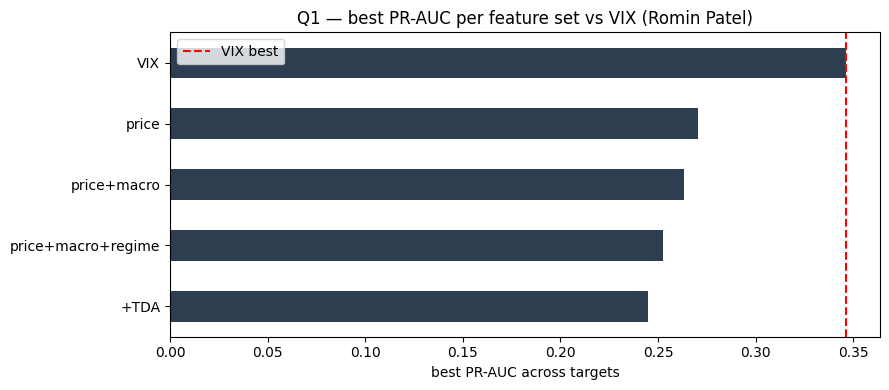

In [25]:
def _safe(o):
    if isinstance(o,float) and (np.isnan(o) or np.isinf(o)): return None
    return str(o)
summary={"config":{"horizons":HORIZONS,"thresholds":THRESHOLDS,"device":DEVICE,
                   "fred":not fred_daily.empty,"macro":MACRO,"tda":TDA,"sentiment":SENT,
                   "rows":int(len(feat))},
         "q1_sweep":sweep.to_dict("records"),
         "q1_winners":(W.to_dict("records") if len(W) else []),
         "q1_real_edge":q1_win,
         "q2":q2}
with open(f"{OUT}/edge_multimodal_results.json","w") as fh: json.dump(summary,fh,indent=2,default=_safe)
# plot: best PR-AUC per feature set vs VIX
try:
    setcols=[c for c in sweep.columns if c.endswith("_PRAUC")]
    bestper={c.replace("_PRAUC",""):sweep[c].max() for c in setcols}
    fig,ax=plt.subplots(figsize=(9,4)); pd.Series(bestper).sort_values().plot(kind="barh",ax=ax,color="#2C3E50")
    ax.axvline(sweep["VIX_PRAUC"].max(),color="red",ls="--",label="VIX best"); ax.set_xlabel("best PR-AUC across targets"); ax.legend()
    ax.set_title("Q1 — best PR-AUC per feature set vs VIX (Romin Patel)"); plt.tight_layout()
    plt.savefig(f"{OUT}/edge_multimodal.png",dpi=150,bbox_inches="tight")
except Exception as e: print("plot skip",e)
print("Saved:", f"{OUT}/edge_multimodal_results.json", "and edge_multimodal.png")
print("\n================ SEND ME edge_multimodal_results.json ================")
print("Q1 real edge over VIX:", q1_win, "| Q2 multimodal validated:", q2.get("validated"))

## 13. How to read this

- **Q1 wins** only if a row in §10 has `WINS_ALL_3 = True` (PR-AUC > VIX **and**
  PBO < 0.5 **and** Deflated Sharpe > 0.95). One gate failing = no honest edge.
- **Q2 validated** only if §11 shows `delta_PRAUC > 0` **and** Granger p < 0.05
  with REAL FinBERT sentiment.
- A clean **NULL** on either is a legitimate, publishable result — it is the
  opposite of the inflated claims the 2024–25 backtest-overfitting / TSFM-leakage
  literature is built to catch.

Send back `edge_multimodal_results.json` and I'll interpret it straight and
write up whichever way it falls. *Author: Romin Patel.*